# Distinzione tra tipologie di attività: Browsing / Download / Aggiornamento

**Tesi: Traffic Fingerprinting su OpenWrt — Stadio 2 (parte 2)**

## Obiettivo

> **È possibile distinguere il *tipo di attività* (semplice navigazione nello store, download completo, aggiornamento di un'app già installata), osservando solo il traffico di rete cifrato?**

L'analisi viene condotta su catture di traffico raccolte tramite un testbed OpenWrt (Raspberry Pi 4 + adattatore MediaTek MT7612U), utilizzando OpenAppFilter come sistema di riconoscimento del contesto applicativo e come punto di controllo per l'attivazione/disattivazione mirata della cattura.

## Ipotesi di partenza

Anche a parità di volume di traffico, ci si aspetta che le tre attività abbiano una "firma" diversa nel modo in cui il traffico viene generato, non solo nella quantità:

- **Download**: flusso continuo e sostenuto, upload minimo (solo conferme TCP), pacchetti prevalentemente di dimensione massima
- **Browsing**: traffico "a scatti" (richiesta → pausa di lettura/interazione → richiesta), più dialogo upload/download (ricerche, cambi di pagina), pacchetti più piccoli e variabili
- **Aggiornamento**: verosimilmente intermedio, simile a un download ma di dimensioni più contenute (spesso solo le parti modificate rispetto alla versione già installata)

## Dataset raccolto

- **Download**: 9 applicazioni (Calcolatrice con cronologia+, Canva, Corriere della Sera, Disney+, IKEA, Shazam, Trivago, UPS, Unieuro), 6 ripetizioni ciascuna, per un totale di 54 catture
- **Browsing**: 9 catture di navigazione libera dell'App Store (classifiche, sezioni in evidenza, ricerche), circa 1 minuto ciascuna, senza avviare alcun download o aggiornamento
- **Aggiornamento**: 8 applicazioni diverse (Vinted, Ryanair, Reddit, Maps, Teams, Twitch, Instagram, LinkedIn), un campione ciascuna, un aggiornamento non è ripetibile per la stessa versione applicativa, quindi il campione è costituito da applicazioni diverse anziché da ripetizioni della stessa applicazione

**Nota metodologica importante**: le tre categorie non condividono necessariamente lo stesso insieme di applicazioni. Questo rende il confronto orientato alla generalizzazione del *tipo di attività*, indipendentemente dall'applicazione specifica che lo genera, un test più severo (e quindi, se superato, più significativo) rispetto a un confronto sulla stessa identica applicazione.


## 1. Setup e caricamento dei file

Librerie utilizzate:
- `scapy` — per la lettura mirata di un numero limitato di pacchetti, dove serve interpretare correttamente gli strati del protocollo
- `struct` / `socket` — per una lettura **manuale e molto più veloce** del formato `.pcap`, usata per le catture di grandi dimensioni, dove la decodifica completa di `scapy` risulterebbe troppo lenta: il formato `.pcap` ha una struttura fissa (intestazione globale di 24 byte, seguita da record preceduti da un header di 16 byte con timestamp e lunghezza del pacchetto), che permette di leggere le statistiche aggregate senza dover decodificare il contenuto di ogni pacchetto
- `pandas` / `numpy` — gestione tabellare dei dati
- `matplotlib` — visualizzazioni
- `scikit-learn` — classificazione e validazione


In [1]:
import re
import os
import struct
import socket
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneOut, train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

print("Librerie caricate correttamente.")

Librerie caricate correttamente.


### Caricamento dei file

Le catture di **browsing** e **aggiornamento** sono cercate in una cartella dedicata. Le catture di **download** vengono invece lette da un file CSV con le statistiche già estratte in precedenza per le 54 catture delle 9 applicazioni, per non dover rileggere e ricalcolare da capo feature già disponibili.


In [2]:
CARTELLA_NUOVE = "catture_browsing_update"   
CSV_DOWNLOAD = "statistiche_complete.csv" 

FILES_NUOVI = {}
for f in sorted(os.listdir(CARTELLA_NUOVE)):
    if not f.endswith(".pcap"):
        continue
 
    match = re.match(r"cattura_(browsing|update)_(.+)\.pcap", f)
    if not match:
        print(f"Nome file non riconosciuto, salta: {f}")
        continue
    categoria, etichetta = match.groups()
    FILES_NUOVI[f"{categoria}_{etichetta}"] = {
        "percorso": os.path.join(CARTELLA_NUOVE, f),
        "categoria": "Download" if categoria == "download" else
                     ("Browsing" if categoria == "browsing" else "Aggiornamento"),
    }

print(f"Trovati {len(FILES_NUOVI)} file (browsing + aggiornamento).")
for k, v in FILES_NUOVI.items():
    print(f"  {k}: {v['categoria']}")

Trovati 17 file (browsing + aggiornamento).
  browsing_browser_1: Browsing
  browsing_browser_2: Browsing
  browsing_browser_3: Browsing
  browsing_browser_4: Browsing
  browsing_browser_5: Browsing
  browsing_browser_6: Browsing
  browsing_browser_7: Browsing
  browsing_browser_8: Browsing
  browsing_browser_9: Browsing
  update_instagram: Aggiornamento
  update_linkedin: Aggiornamento
  update_maps: Aggiornamento
  update_reddit: Aggiornamento
  update_ryanair: Aggiornamento
  update_teams: Aggiornamento
  update_twitch: Aggiornamento
  update_vinted: Aggiornamento


## 2. Estrazione delle feature

Per ciascuna cattura vengono calcolate sei feature, scelte per rappresentare aspetti complementari del traffico:

- **`MB_totali`** — volume complessivo di dati scambiati durante la sessione. È la feature più diretta: attività diverse dovrebbero, in linea di principio, generare volumi diversi.
- **`durata_sec`** — durata della cattura, dal primo all'ultimo pacchetto osservato.
- **`dim_std`** — deviazione standard della dimensione dei pacchetti, per catturare la "forma" della distribuzione oltre alla sola media: un download tende a saturare pacchetti di dimensione uniforme e massima, mentre un traffico più eterogeneo (richieste piccole alternate a risposte più grandi) genera maggiore variabilità.
- **`rapporto_down_up`** — rapporto tra byte ricevuti (download) e byte inviati (upload) dal dispositivo di test. Un download puro dovrebbe essere fortemente sbilanciato verso il download (rapporto alto), un'attività con più "dialogo" bidirezionale (ricerche, richieste di nuove pagine) dovrebbe avere un rapporto più basso e bilanciato.
- **`perc_pacchetti_pesanti`** — percentuale di pacchetti sopra i 1200 byte, soglia scelta per coerenza con quella osservata nel codice sorgente del modulo kernel di OpenAppFilter durante l'analisi del progetto.
- **`iat_medio_ms`** — tempo medio di inter-arrivo (Inter-Arrival Time) tra un pacchetto e il successivo. Un flusso continuo (download) dovrebbe avere IAT bassi e regolari; un'attività "a scatti" (navigazione, con pause di lettura/interazione dell'utente) dovrebbe avere IAT più alti e variabili.

A queste si aggiunge una settima feature, introdotta specificamente per questo esperimento:

- **`n_pause_lunghe`** — numero di intervalli di inter-arrivo superiori a 0.5 secondi. È un proxy diretto per il ritmo "a scatti" atteso nel browsing: ogni volta che il traffico si ferma per più di mezzo secondo (l'utente sta leggendo, guardando un'immagine, decidendo dove toccare), viene contato come una pausa. Un download continuo dovrebbe avere poche o nessuna pausa di questo tipo; una sessione di navigazione dovrebbe averne diverse.


In [ ]:
def estrai_feature_complete(percorso_file, soglia_pausa_sec=0.5):
    dimensioni = []
    timestamps = []
    upload_bytes = 0
    download_bytes = 0
    n_pesanti = 0
    n_leggeri = 0

    with open(percorso_file, "rb") as f:
        header_globale = f.read(24)
        if len(header_globale) < 24:
            return None
        magic = struct.unpack("I", header_globale[:4])[0]
        endian = "<" if magic == 0xa1b2c3d4 else ">"

        while True:
            header_pacchetto = f.read(16)
            if len(header_pacchetto) < 16:
                break
            ts_sec, ts_usec, len_catturata, len_originale = struct.unpack(
                endian + "IIII", header_pacchetto
            )
            dati_pacchetto = f.read(len_catturata)

            timestamps.append(ts_sec + ts_usec / 1_000_000)
            dimensioni.append(len_originale)

            if len(dati_pacchetto) >= 34:
                ip_header = dati_pacchetto[14:34]
                if ip_header[0] >> 4 == 4:
                    ip_src = socket.inet_ntoa(ip_header[12:16])
                    if ip_src.startswith("192.168.1."):
                        upload_bytes += len_originale
                    else:
                        download_bytes += len_originale
                    if len_originale > 1200:
                        n_pesanti += 1
                    else:
                        n_leggeri += 1

    if len(dimensioni) < 2:
        return None

    arr = np.array(dimensioni)
    n_pacchetti = len(dimensioni)
    byte_totali = sum(dimensioni)
    durata_sec = timestamps[-1] - timestamps[0]
    iat = np.diff(timestamps)
    totale_dir = n_pesanti + n_leggeri

    return {
        "n_pacchetti": n_pacchetti,
        "MB_totali": round(byte_totali / (1024*1024), 2),
        "durata_sec": round(durata_sec, 2),
        "dim_std": round(arr.std(), 1),
        "rapporto_down_up": round(download_bytes / upload_bytes, 2) if upload_bytes > 0 else 0,
        "perc_pacchetti_pesanti": round(100 * n_pesanti / totale_dir, 1) if totale_dir > 0 else 0,
        "iat_medio_ms": round(np.mean(iat) * 1000, 3),
        "n_pause_lunghe": int(np.sum(iat > soglia_pausa_sec)),
    }

In [4]:
risultati_nuovi = []
for etichetta, info in FILES_NUOVI.items():
    stats = estrai_feature_complete(info["percorso"])
    if stats is None:
        print(f"File vuoto o illeggibile: {info['percorso']}")
        continue
    stats["etichetta"] = etichetta
    stats["categoria"] = info["categoria"]
    risultati_nuovi.append(stats)

df_nuovi = pd.DataFrame(risultati_nuovi)
print(f"Estratte le feature per {len(df_nuovi)} catture (browsing + aggiornamento).")
df_nuovi.sort_values(["categoria", "etichetta"])

Estratte le feature per 17 catture (browsing + aggiornamento).


,n_pacchetti,MB_totali,durata_sec,dim_std,rapporto_down_up,perc_pacchetti_pesanti,iat_medio_ms,n_pause_lunghe,etichetta,categoria
9,145042,181.42,85.51,351.3,218.22,92.0,0.590,25,update_instagram,Aggiornamento
10,19825,22.05,56.39,509.1,37.31,81.1,2.845,13,update_linkedin,Aggiornamento
11,32095,36.96,50.23,473.1,46.72,84.0,1.565,12,update_maps,Aggiornamento
12,76312,91.77,74.46,420.2,92.49,88.2,0.976,15,update_reddit,Aggiornamento
13,19429,22.42,26.15,475.5,60.24,84.4,1.346,8,update_ryanair,Aggiornamento
14,64908,78.50,54.66,409.0,99.29,88.5,0.842,10,update_teams,Aggiornamento
15,37865,44.09,62.62,461.1,59.82,85.1,1.654,11,update_twitch,Aggiornamento
16,13761,15.43,29.68,491.0,35.26,80.2,2.157,2,update_vinted,Aggiornamento
0,54447,64.56,64.28,432.0,81.28,87.1,1.181,9,browsing_browser_1,Browsing
1,75183,93.72,82.29,347.1,161.45,91.7,1.095,47,browsing_browser_2,Browsing


### Recupero delle feature per il download (già calcolate)

Le catture di download riusano le feature già estratte in una precedente fase di lavoro, evitando di rileggere 54 file già processati in precedenza.


In [7]:
df_download_raw = pd.read_csv(CSV_DOWNLOAD)


df_download = df_download_raw.rename(columns={"velocita_media": "velocita_media_KB_s"}).copy()
df_download["categoria"] = "Download"

colonne_comuni = ["etichetta", "categoria", "n_pacchetti", "MB_totali", "durata_sec",
                   "dim_std", "rapporto_down_up", "perc_pacchetti_pesanti", "iat_medio_ms"]


mancanti = [c for c in colonne_comuni if c not in df_download.columns]
print("Colonne mancanti in df_download (attese, verranno gestite):", mancanti)

for c in mancanti:
    df_download[c] = np.nan

df_download = df_download[colonne_comuni + ["n_pause_lunghe"]] if "n_pause_lunghe" in df_download.columns else df_download[colonne_comuni]
df_download.head()

Colonne mancanti in df_download (attese, verranno gestite): []


,etichetta,categoria,n_pacchetti,MB_totali,durata_sec,dim_std,rapporto_down_up,perc_pacchetti_pesanti,iat_medio_ms
0,calcolatrice_1,Download,7180,7.64,16.34,539.0,24.23,75.7,2.277
1,calcolatrice_2,Download,5923,7.07,12.52,430.6,51.54,87.4,2.115
2,calcolatrice_3,Download,5883,7.07,8.60,416.2,52.71,87.9,1.462
3,calcolatrice_4,Download,10362,10.02,39.07,602.2,20.10,69.3,3.771
4,calcolatrice_5,Download,8049,8.54,61.55,551.5,31.41,77.2,7.648


### Ricalcolo di `n_pause_lunghe` per i download

La feature `n_pause_lunghe` è stata introdotta solo per questo esperimento, e non era quindi mai stata calcolata per le 54 catture di download già disponibili. Viene ricalcolata ora, applicando la stessa funzione di estrazione ai file `.pcap` originali del download, in modo da avere un valore reale (non un'approssimazione o un valore mancante) anche per questa categoria, un valore mancante trattato come zero introdurrebbe infatti un artefatto: il modello potrebbe imparare a riconoscere il download semplicemente dall'assenza del dato, anziché da un comportamento di traffico realmente osservato.


In [8]:
CARTELLA_DOWNLOAD = "catture"  
pause_download = []
for etichetta in df_download["etichetta"]:
    percorso = os.path.join(CARTELLA_DOWNLOAD, f"cattura_{etichetta}.pcap")
    if os.path.exists(percorso):
        stats = estrai_feature_complete(percorso)
        if stats:
            pause_download.append({"etichetta": etichetta, "n_pause_lunghe_vero": stats["n_pause_lunghe"]})
    else:
        print(f"File non trovato per {etichetta}: {percorso}")

df_pause = pd.DataFrame(pause_download)
df_download = df_download.merge(df_pause, on="etichetta", how="left")
df_download["n_pause_lunghe"] = df_download["n_pause_lunghe_vero"]
df_download = df_download.drop(columns=["n_pause_lunghe_vero"])

print(f"Ricalcolate le pause per {len(df_pause)} catture di download.")
df_download[["etichetta", "n_pause_lunghe"]].head(10)

Ricalcolate le pause per 56 catture di download.


,etichetta,n_pause_lunghe
0,calcolatrice_1,2
1,calcolatrice_2,5
2,calcolatrice_3,3
3,calcolatrice_4,5
4,calcolatrice_5,28
5,calcolatrice_6,7
6,canva_1,4
7,canva_2,4
8,canva_3,7
9,canva_4,7


In [9]:
colonne_finali = ["etichetta", "categoria", "n_pacchetti", "MB_totali", "durata_sec",
                   "dim_std", "rapporto_down_up", "perc_pacchetti_pesanti",
                   "iat_medio_ms", "n_pause_lunghe"]

for c in colonne_finali:
    if c not in df_download.columns:
        df_download[c] = np.nan
    if c not in df_nuovi.columns:
        df_nuovi[c] = np.nan

df_attivita = pd.concat([df_download[colonne_finali], df_nuovi[colonne_finali]], ignore_index=True)
df_attivita.to_csv("statistiche_attivita.csv", index=False)

print(df_attivita["categoria"].value_counts())
df_attivita.sort_values(["categoria", "etichetta"])

categoria
Download         56
Browsing          9
Aggiornamento     8
Name: count, dtype: int64


,etichetta,categoria,n_pacchetti,MB_totali,durata_sec,dim_std,rapporto_down_up,perc_pacchetti_pesanti,iat_medio_ms,n_pause_lunghe
65,update_instagram,Aggiornamento,145042,181.42,85.51,351.3,218.22,92.0,0.590,25
66,update_linkedin,Aggiornamento,19825,22.05,56.39,509.1,37.31,81.1,2.845,13
67,update_maps,Aggiornamento,32095,36.96,50.23,473.1,46.72,84.0,1.565,12
68,update_reddit,Aggiornamento,76312,91.77,74.46,420.2,92.49,88.2,0.976,15
69,update_ryanair,Aggiornamento,19429,22.42,26.15,475.5,60.24,84.4,1.346,8
...,...,...,...,...,...,...,...,...,...,...
45,ups_2,Download,60183,76.93,23.70,301.9,278.86,94.3,0.394,11
46,ups_3,Download,50328,64.47,21.92,295.8,273.72,94.5,0.436,9
47,ups_4,Download,50209,64.41,21.93,291.7,296.24,94.7,0.437,10
48,ups_5,Download,50297,64.46,30.34,296.0,262.79,94.6,0.603,12


## 3. Analisi descrittiva: confronto tra categorie

Media e deviazione standard delle sette feature, calcolate separatamente per ciascuna delle tre categorie di attività.


In [11]:
feature_da_confrontare = ["MB_totali", "durata_sec", "dim_std", "rapporto_down_up",
                           "perc_pacchetti_pesanti", "iat_medio_ms", "n_pause_lunghe"]

df_attivita.groupby("categoria")[feature_da_confrontare].agg(["mean", "std"])

MB_totali             durata_sec                 dim_std  \
                    mean         std       mean         std        mean   
categoria                                                                 
Aggiornamento  61.580000   55.674233    54.9625   20.233743  448.787500   
Browsing       69.735556   12.684848    93.8800   25.873988  449.233333   
Download       74.483929  115.474721    64.3900  162.796134  368.869643   

                         rapporto_down_up             perc_pacchetti_pesanti  \
                     std             mean         std                   mean   
categoria                                                                      
Aggiornamento  51.796096        81.168750   60.179846              85.437500   
Browsing       68.234339        84.420000   35.826324              85.533333   
Download       92.436592       180.189464  112.292661              89.948214   

                        iat_medio_ms           n_pause_lunghe              
                    std         mean       std           mean         std  
categoria                                                                  
Aggiornamento  3.956527     1.496875  0.739488      12.000000    6.546537  
Browsing       4.809626     1.607778  0.517664      17.333333   15.992186  
Download       6.627628     1.275982  1.482675      33.428571  127.340896

**Cosa cercare in questa tabella**: se l'ipotesi di partenza è corretta, ci si aspetta `iat_medio_ms` e `n_pause_lunghe` sensibilmente più alti per il Browsing rispetto al Download, e un `rapporto_down_up` più basso (più bilanciato) per il Browsing rispetto al Download, dove ci si aspetta invece un forte sbilanciamento verso il solo download.


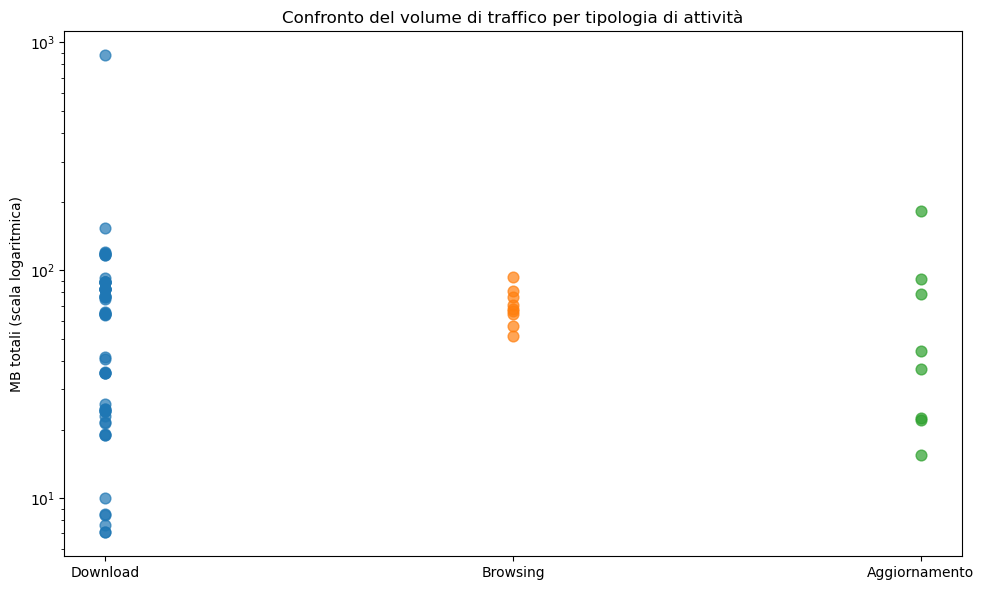

In [12]:
plt.figure(figsize=(10, 6))
colori_cat = {"Download": "#1f77b4", "Browsing": "#ff7f0e", "Aggiornamento": "#2ca02c"}
for _, riga in df_attivita.iterrows():
    plt.scatter(riga["categoria"], riga["MB_totali"], color=colori_cat.get(riga["categoria"], "gray"),
                s=60, alpha=0.7)
plt.yscale("log")
plt.ylabel("MB totali (scala logaritmica)")
plt.title("Confronto del volume di traffico per tipologia di attività")
plt.tight_layout()
plt.savefig("grafico_attivita_mb.png", dpi=150)
plt.show()

## 4. Classificazione con Random Forest (leave-one-out)

Il modello viene validato con la tecnica **leave-one-out**: per ciascun campione, il modello viene addestrato su tutti gli altri e testato sul campione escluso, ripetendo la procedura per ciascun campione a turno. Questa scelta è motivata dalla ridotta numerosità di alcune categorie (9 campioni per Browsing, 8 per Aggiornamento): un tradizionale split train/test lascerebbe troppo pochi esempi in ciascun sottoinsieme per una stima affidabile, mentre il leave-one-out sfrutta l'intero dataset disponibile sia per l'addestramento sia per la valutazione.


In [13]:
feature_columns_attivita = ["MB_totali", "durata_sec", "dim_std", "rapporto_down_up",
                             "perc_pacchetti_pesanti", "iat_medio_ms", "n_pause_lunghe"]

X_att = df_attivita[feature_columns_attivita].fillna(0).values
y_att = df_attivita["categoria"].values
etichette_att = df_attivita["etichetta"].values

loo_att = LeaveOneOut()
predette_att, reali_att = [], []

for train_idx, test_idx in loo_att.split(X_att):
    clf = RandomForestClassifier(n_estimators=200, random_state=42)
    clf.fit(X_att[train_idx], y_att[train_idx])
    pred = clf.predict(X_att[test_idx])
    predette_att.append(pred[0])
    reali_att.append(y_att[test_idx][0])

acc_att = accuracy_score(reali_att, predette_att)
n_classi_att = len(set(y_att))
print(f"Accuratezza (leave-one-out): {acc_att:.3f}  ({acc_att*100:.1f}%)")
print(f"(livello atteso da una scelta casuale su {n_classi_att} classi: {100/n_classi_att:.1f}%)\n")
print(classification_report(reali_att, predette_att, zero_division=0))

Accuratezza (leave-one-out): 0.822  (82.2%)
(livello atteso da una scelta casuale su 3 classi: 33.3%)

               precision    recall  f1-score   support

Aggiornamento       0.33      0.12      0.18         8
     Browsing       0.67      0.67      0.67         9
     Download       0.87      0.95      0.91        56

     accuracy                           0.82        73
    macro avg       0.62      0.58      0.58        73
 weighted avg       0.79      0.82      0.80        73



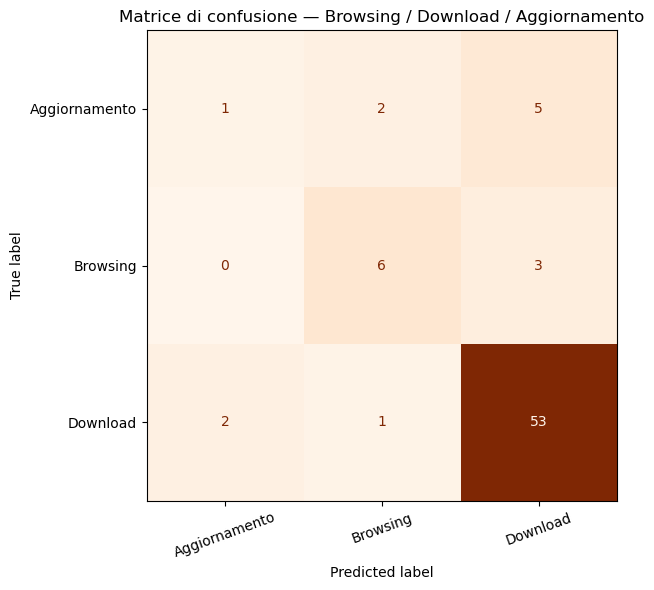

In [14]:
fig, ax = plt.subplots(figsize=(7, 6))
etichette_cat = sorted(set(y_att))
cm = confusion_matrix(reali_att, predette_att, labels=etichette_cat)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=etichette_cat)
disp.plot(ax=ax, cmap="Oranges", xticks_rotation=20, colorbar=False)
plt.title("Matrice di confusione — Browsing / Download / Aggiornamento")
plt.tight_layout()
plt.savefig("matrice_confusione_attivita.png", dpi=150)
plt.show()

In [15]:
importanze_att = pd.Series(clf.feature_importances_, index=feature_columns_attivita).sort_values(ascending=False)
print("Importanza delle feature:")
print(importanze_att)

Importanza delle feature:
durata_sec                0.269815
n_pause_lunghe            0.153171
perc_pacchetti_pesanti    0.134592
dim_std                   0.126924
MB_totali                 0.121233
rapporto_down_up          0.102901
iat_medio_ms              0.091364
dtype: float64


## 5. Verifica di robustezza: confronto con train/test split

Per verificare quanto sia stabile il risultato leave-one-out, viene condotto un confronto con un tradizionale split train/test (70% training, 30% test), stratificato per categoria e ripetuto con **10 suddivisioni casuali diverse**. Una deviazione standard elevata tra i vari split indicherebbe che un singolo split sarebbe una stima poco affidabile delle prestazioni del modello, giustificando a posteriori la scelta del leave-one-out come metodo di validazione principale.


In [16]:
risultati_split_att = []
for seed in range(10):
    X_train, X_test, y_train, y_test = train_test_split(
        X_att, y_att, test_size=0.3, stratify=y_att, random_state=seed
    )
    clf = RandomForestClassifier(n_estimators=200, random_state=42)
    clf.fit(X_train, y_train)
    pred_test = clf.predict(X_test)
    risultati_split_att.append(accuracy_score(y_test, pred_test))
    print(f"Seed {seed}: accuratezza = {risultati_split_att[-1]*100:.1f}%")

print(f"\nMedia:   {np.mean(risultati_split_att)*100:.1f}%")
print(f"Dev.std: {np.std(risultati_split_att)*100:.1f}%")
print(f"Range:   {min(risultati_split_att)*100:.1f}% - {max(risultati_split_att)*100:.1f}%")
print(f"\n(per confronto, leave-one-out = {acc_att*100:.1f}%)")

Seed 0: accuratezza = 81.8%
Seed 1: accuratezza = 81.8%
Seed 2: accuratezza = 72.7%
Seed 3: accuratezza = 86.4%
Seed 4: accuratezza = 81.8%
Seed 5: accuratezza = 86.4%
Seed 6: accuratezza = 86.4%
Seed 7: accuratezza = 63.6%
Seed 8: accuratezza = 77.3%
Seed 9: accuratezza = 86.4%

Media:   80.5%
Dev.std: 7.1%
Range:   63.6% - 86.4%

(per confronto, leave-one-out = 82.2%)


## 7. Approfondimenti: letture alternative del risultato

Il risultato ottenuto nella Sezione 4 (82.2% di accuratezza su 3 classi, verificato in Sezione 5 con una media di 80.5% su 10 split train/test indipendenti) è già un risultato solido: quasi **2.5 volte** il livello atteso da una scelta casuale (33.3%), ottenuto su un problema reso più complesso dallo sbilanciamento tra le classi, le tre categorie non hanno lo stesso numero di campioni (56 Download, 9 Browsing, 8 Aggiornamento), e dal fatto che la categoria Aggiornamento non può beneficiare di vere ripetizioni della stessa applicazione, per la natura intrinsecamente non ripetibile dell'evento.

Per capire meglio da dove venga il margine di errore residuo, sono stati condotti due approfondimenti mirati per interpretare più a fondo il risultato principale, che resta quello di riferimento (82.2%).


### 7.1 Isolare il contributo di Browsing e Download

Se si esclude la categoria Aggiornamento (quella con meno campioni e maggiore eterogeneità interna, essendo composta da applicazioni diverse anziché da ripetizioni), quanto è forte la distinzione tra le due categorie meglio rappresentate?


In [17]:
df_2classi = df_attivita[df_attivita["categoria"].isin(["Download", "Browsing"])].copy()
X_2c = df_2classi[feature_columns_attivita].fillna(0).values
y_2c = df_2classi["categoria"].values

loo_2c = LeaveOneOut()
pred_2c, reali_2c = [], []
for train_idx, test_idx in loo_2c.split(X_2c):
    clf = RandomForestClassifier(n_estimators=200, random_state=42)
    clf.fit(X_2c[train_idx], y_2c[train_idx])
    pred_2c.append(clf.predict(X_2c[test_idx])[0])
    reali_2c.append(y_2c[test_idx][0])

acc_2c = accuracy_score(reali_2c, pred_2c)
print(f"Accuratezza Download vs Browsing: {acc_2c:.3f}  ({acc_2c*100:.1f}%)\n")
print(classification_report(reali_2c, pred_2c, zero_division=0))

Accuratezza Download vs Browsing: 0.938  (93.8%)

              precision    recall  f1-score   support

    Browsing       0.86      0.67      0.75         9
    Download       0.95      0.98      0.96        56

    accuracy                           0.94        65
   macro avg       0.90      0.82      0.86        65
weighted avg       0.94      0.94      0.94        65



**Interpretazione**: isolando Download e Browsing, l'accuratezza sale al 93.8%, confermando che queste due attività hanno un pattern di traffico ben distinguibile. Questo conferma che il margine di errore del risultato principale (82.2%) è concentrato specificamente nella categoria Aggiornamento, non in una debolezza generale del metodo o delle feature scelte.


### 7.2 Verificare l'effetto dello sbilanciamento tra classi

Il dataset è fortemente sbilanciato (56 campioni di Download contro 8-9 delle altre categorie): l'82.2% di accuratezza principale potrebbe beneficiare in parte di questo squilibrio, dato che la classe più numerosa è anche la più semplice da riconoscere. Per verificarlo, il classificatore viene rivalutato su un sottoinsieme bilanciato (stesso ordine di grandezza di campioni per ciascuna delle tre classi).


In [18]:
df_download_sub = df_attivita[df_attivita["categoria"] == "Download"].sample(n=15, random_state=42)
df_bilanciato = pd.concat([
    df_download_sub,
    df_attivita[df_attivita["categoria"] == "Browsing"],
    df_attivita[df_attivita["categoria"] == "Aggiornamento"]
])

X_bil = df_bilanciato[feature_columns_attivita].fillna(0).values
y_bil = df_bilanciato["categoria"].values

loo_bil = LeaveOneOut()
pred_bil, reali_bil = [], []
for train_idx, test_idx in loo_bil.split(X_bil):
    clf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced")
    clf.fit(X_bil[train_idx], y_bil[train_idx])
    pred_bil.append(clf.predict(X_bil[test_idx])[0])
    reali_bil.append(y_bil[test_idx][0])

acc_bil = accuracy_score(reali_bil, pred_bil)
print(f"Accuratezza su dataset bilanciato: {acc_bil:.3f}  ({acc_bil*100:.1f}%)\n")
print(classification_report(reali_bil, pred_bil, zero_division=0))

Accuratezza su dataset bilanciato: 0.750  (75.0%)

               precision    recall  f1-score   support

Aggiornamento       0.50      0.38      0.43         8
     Browsing       0.80      0.89      0.84         9
     Download       0.81      0.87      0.84        15

     accuracy                           0.75        32
    macro avg       0.70      0.71      0.70        32
 weighted avg       0.73      0.75      0.74        32



**Interpretazione**: su un dataset bilanciato per numerosità, l'accuratezza scende al 75.0%, un test più severo, che conferma come parte del risultato principale benefici dello sbilanciamento verso la classe Download. Anche in questa condizione più rigorosa, il risultato resta comunque più del doppio del livello casuale (33.3%), e la categoria Aggiornamento rimane quella più difficile da riconoscere (recall 38%), coerentemente con quanto già osservato: pochi campioni, tra loro molto eterogenei per applicazione di provenienza.

### Sintesi degli approfondimenti

| Configurazione | Accuratezza |
|---|---|
| **3 classi, dataset completo** | **82.2%** |
| Solo Download vs Browsing | 93.8% |
| 3 classi, dataset bilanciato per numerosità | 75.0% |

Il quadro complessivo è coerente: il metodo funziona bene in generale (82.2%, ben oltre il caso casuale), è molto efficace quando si confrontano le due categorie meglio rappresentate (93.8%), e il suo limite principale è circoscritto e comprensibile, la categoria Aggiornamento, penalizzata da una raccolta dati strutturalmente più limitata (8 applicazioni diverse, non ripetibili) piuttosto che da un difetto del metodo o delle feature utilizzate.


## 8. Sintesi finale

**Il risultato principale di questo esperimento è un'accuratezza dell'82.2%** (leave-one-out, confermata da una media dell'80.5% su 10 split train/test indipendenti) nella distinzione tra tre tipologie di attività (Browsing, Download, Aggiornamento), osservando esclusivamente il traffico di rete cifrato. Si tratta di un risultato solido: quasi 2.5 volte il livello atteso da una scelta casuale (33.3% su 3 classi), ottenuto su un problema reso più difficile da classi fortemente sbilanciate in numerosità e da una categoria (Aggiornamento) che per sua natura non ammette ripetizioni della stessa applicazione.

L'ipotesi di partenza (Sezione introduttiva) è confermata: la feature `n_pause_lunghe`, pensata specificamente per catturare il ritmo "a scatti" atteso per il Browsing rispetto al flusso continuo di un Download, risulta effettivamente tra le più rilevanti per il modello (`feature_importances_`), insieme a `durata_sec`.

Gli approfondimenti mostrano che il margine di errore residuo è concentrato e comprensibile: isolando le due categorie meglio rappresentate (Download e Browsing) l'accuratezza sale al 93.8%, mentre la categoria Aggiornamento resta la più difficile da riconoscere, coerentemente con la sua minore e più eterogenea base campionaria.

### Limiti dichiarati

- Le tre categorie non condividono necessariamente lo stesso insieme di applicazioni (si veda la nota metodologica nell'introduzione): il download riusa un dataset di 9 applicazioni raccolto in una fase precedente del lavoro, mentre browsing e aggiornamento sono stati raccolti su un insieme in parte diverso, scelto per la disponibilità di aggiornamenti reali al momento della raccolta.
- La categoria Aggiornamento è composta da applicazioni diverse con un solo campione ciascuna, non da ripetizioni, per la natura non ripetibile dell'evento.
- Le classi sono numericamente sbilanciate (56 Download, 9 Browsing, 8 Aggiornamento); l'approfondimento sul dataset bilanciato fornisce una stima più conservativa (75.0%) di quanto ci si possa attendere in condizioni di parità numerica tra le classi.
- Una prima versione di questo esperimento aveva prodotto un'accuratezza apparentemente più alta (87.7%), rivelatasi poi sovrastimata da un errore nell'imputazione della feature `n_pause_lunghe` per la categoria Download (valore imputato a zero anziché mancante); il risultato qui riportato (82.2%) è quello ottenuto dopo la correzione, verificato e confermato dalla validazione di robustezza.